In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression

root_directory = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'

files = [file for file in os.listdir(root_directory) if file.lower().endswith('.csv')]
files.sort()

files = files[:33]

y_values = [0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9, 0.8, 0.8, 0.8,
           0.7, 0.7, 0.7, 0.6, 0.6, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 
           0.3, 0.3, 0.3, 0.2, 0.2, 0.2]

if len(files) != len(y_values):
    raise ValueError("Number of Y values does not match number of files!")

rows = []

for file, y_value in zip(files, y_values):
    file_path = os.path.join(root_directory, file)
    data = pd.read_csv(file_path, header=None, skiprows=1)
    x_column = data.iloc[:, 1].values
    row = np.insert(x_column, 0, y_value)
    rows.append(row)

columns = ['y'] + [f'x{i+1}' for i in range(len(x_column))]
final_df = pd.DataFrame(rows, columns=columns)

print(final_df.head())

     y        x1        x2        x3        x4        x5        x6        x7  \
0  0.1  96.42178  96.73526  97.08696  97.48573  97.90762  98.30242  98.61735   
1  0.1  94.88798  94.77357  94.57670  94.37805  94.23810  94.18996  94.24100   
2  0.1  93.81363  94.48710  94.91174  95.08084  95.02625  94.81781  94.55362   
3  0.0  96.55682  96.94276  97.27303  97.54424  97.74432  97.86996  97.94167   
4  0.0  99.31718  99.34827  99.38692  99.45122  99.53219  99.60973  99.67068   

         x8        x9  ...     x7459     x7460     x7461     x7462     x7463  \
0  98.82209  98.92204  ...  88.13792  88.14457  88.14877  88.14815  88.14097   
1  94.38189  94.59738  ...  86.48448  86.49870  86.51332  86.52503  86.53049   
2  94.33720  94.25089  ...  83.75468  83.77602  83.79831  83.81705  83.82767   
3  98.00403  98.11266  ...  84.39698  84.40326  84.40857  84.41041  84.40598   
4  99.71947  99.77927  ...  87.44954  87.46559  87.48314  87.49653  87.50082   

      x7464     x7465     x7466     x7

In [3]:
y = final_df.iloc[:, 0]
X = final_df.iloc[:, 1:]
print(X.head())

         x1        x2        x3        x4        x5        x6        x7  \
0  96.42178  96.73526  97.08696  97.48573  97.90762  98.30242  98.61735   
1  94.88798  94.77357  94.57670  94.37805  94.23810  94.18996  94.24100   
2  93.81363  94.48710  94.91174  95.08084  95.02625  94.81781  94.55362   
3  96.55682  96.94276  97.27303  97.54424  97.74432  97.86996  97.94167   
4  99.31718  99.34827  99.38692  99.45122  99.53219  99.60973  99.67068   

         x8        x9       x10  ...     x7459     x7460     x7461     x7462  \
0  98.82209  98.92204  98.95562  ...  88.13792  88.14457  88.14877  88.14815   
1  94.38189  94.59738  94.87569  ...  86.48448  86.49870  86.51332  86.52503   
2  94.33720  94.25089  94.33616  ...  83.75468  83.77602  83.79831  83.81705   
3  98.00403  98.11266  98.31223  ...  84.39698  84.40326  84.40857  84.41041   
4  99.71947  99.77927  99.88290  ...  87.44954  87.46559  87.48314  87.49653   

      x7463     x7464     x7465     x7466     x7467     x7468  
0  8

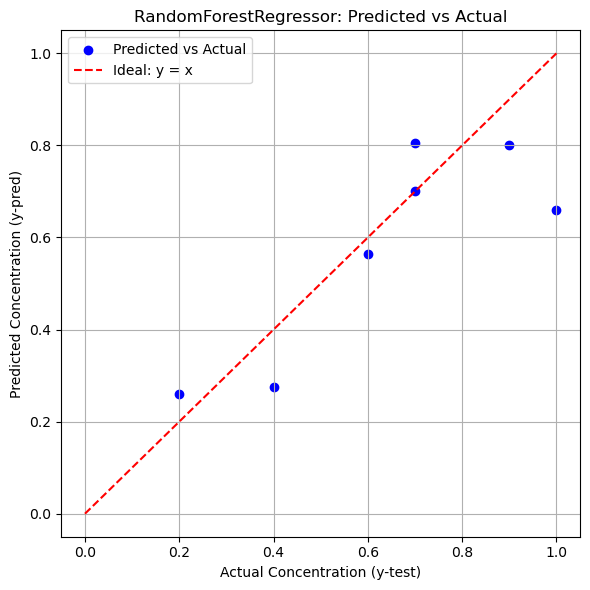

RandomForest R^2 Score: 0.6564


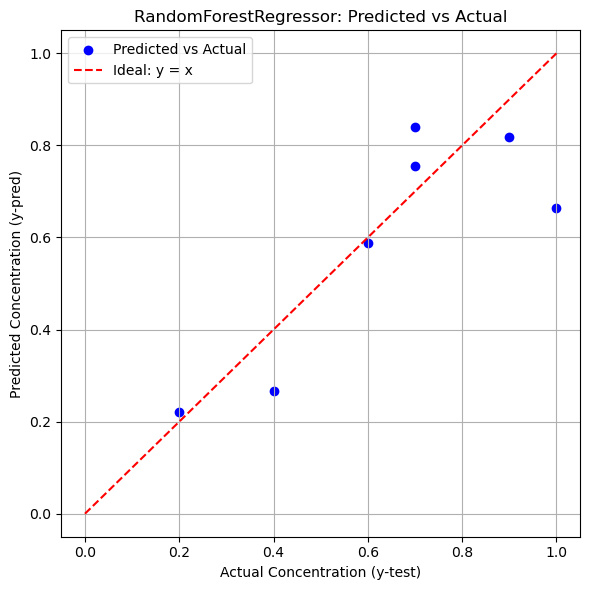

RandomForest R^2 Score: 0.6505


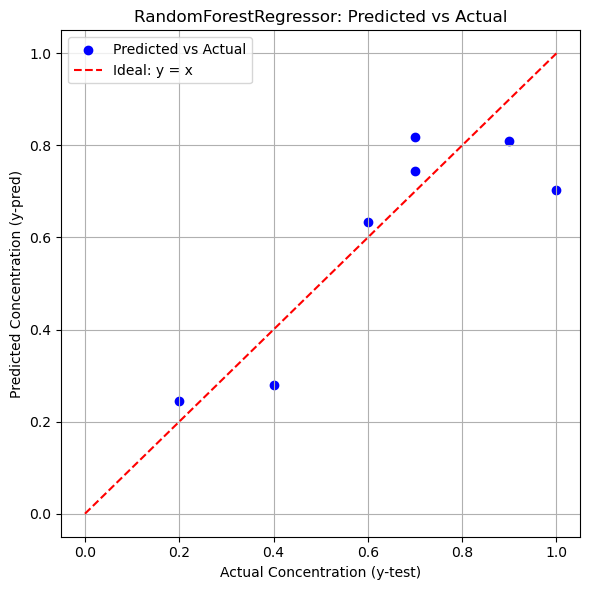

RandomForest R^2 Score: 0.7163


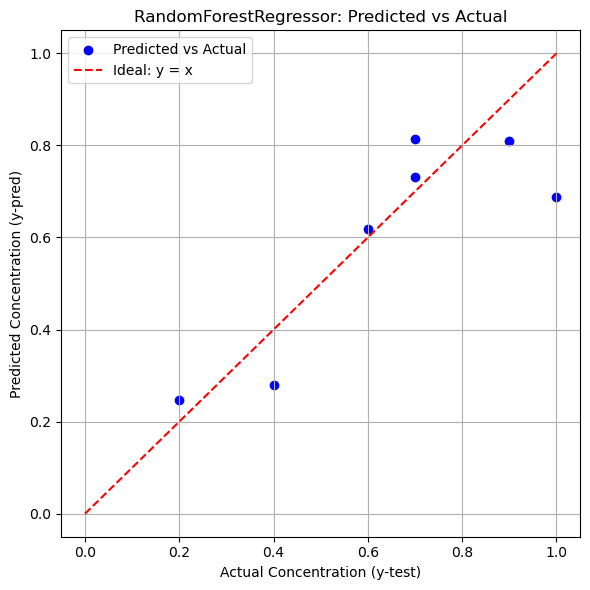

RandomForest R^2 Score: 0.7024


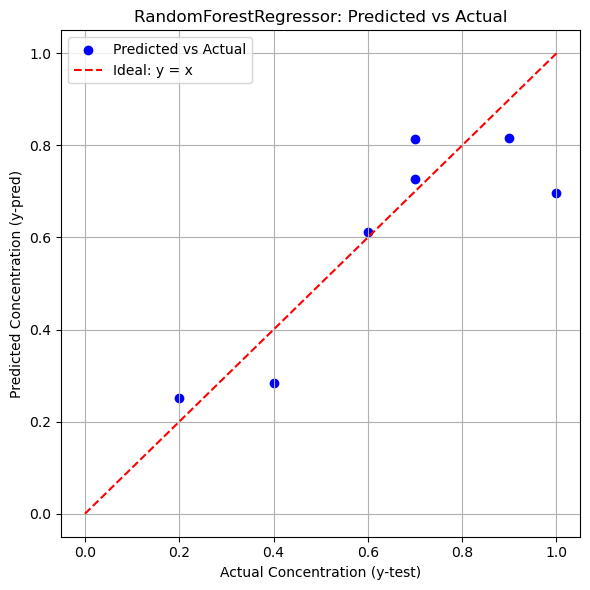

RandomForest R^2 Score: 0.7161


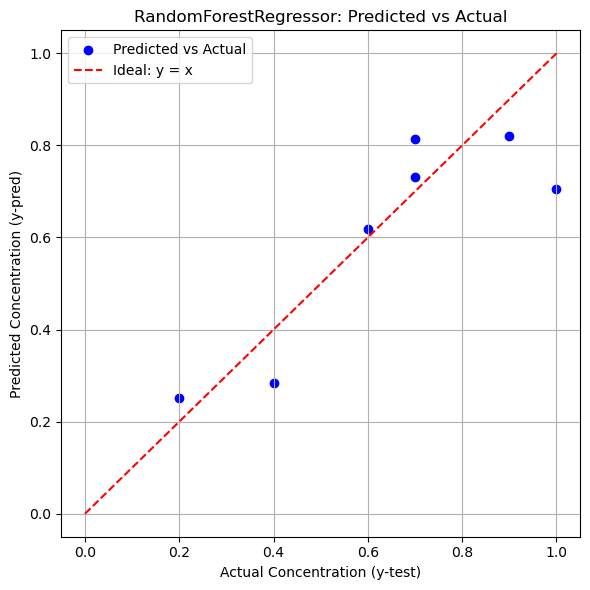

RandomForest R^2 Score: 0.7291


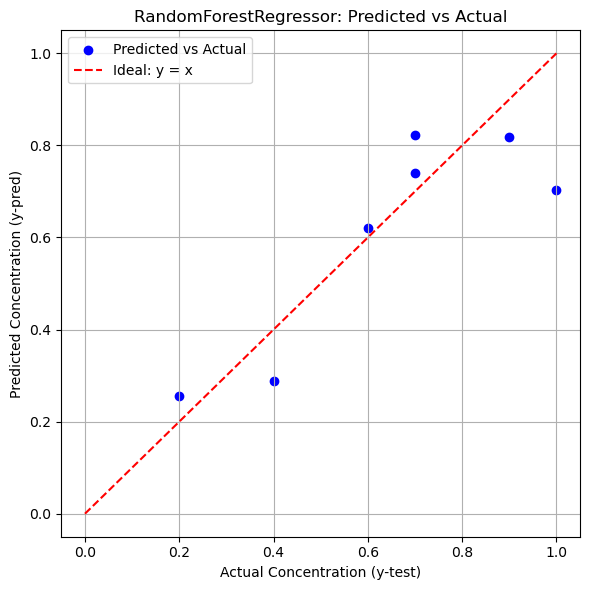

RandomForest R^2 Score: 0.7217


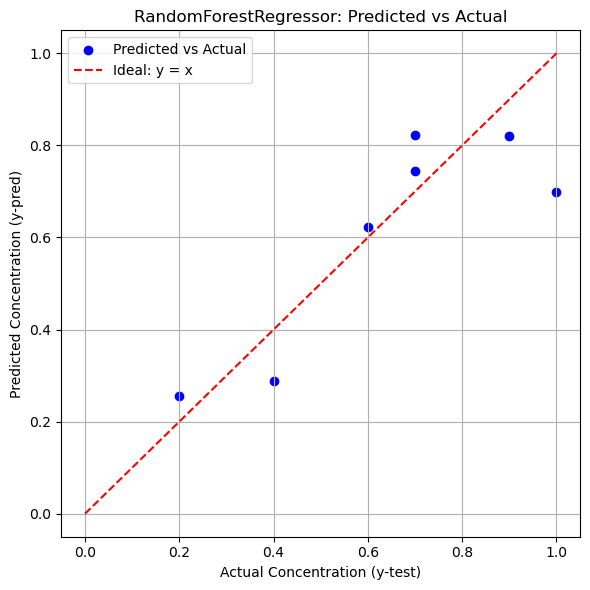

RandomForest R^2 Score: 0.7166


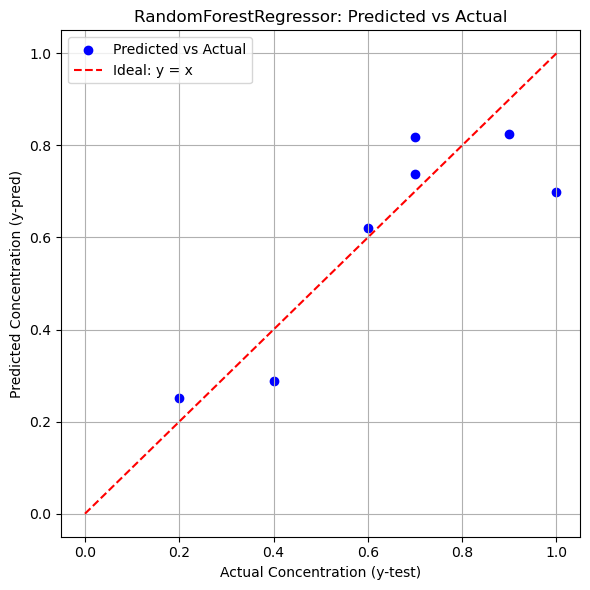

RandomForest R^2 Score: 0.7220


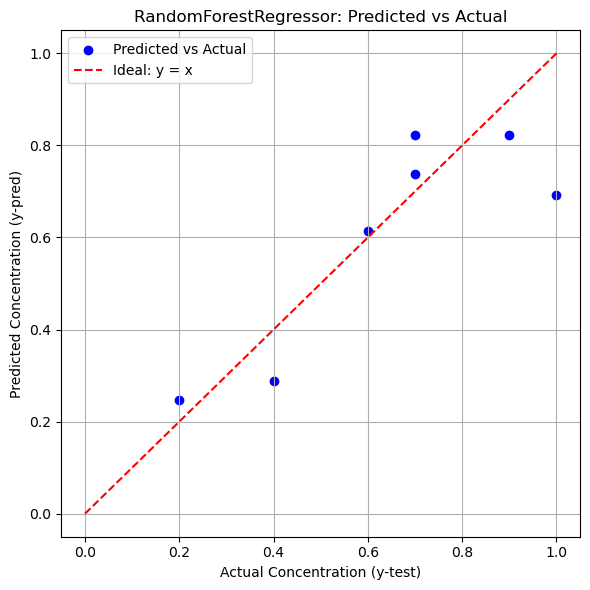

RandomForest R^2 Score: 0.7101


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for t in [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]:
    #plt.figure()
    model = RandomForestRegressor(n_estimators=t, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
    #plt.plot(y_test, y_pred, color='blue', label='Predicted vs Actual')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal: y = x')
    plt.xlabel('Actual Concentration (y-test)')
    plt.ylabel('Predicted Concentration (y-pred)')
    plt.title('RandomForestRegressor: Predicted vs Actual')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"RandomForest R^2 Score: {score:.4f}")

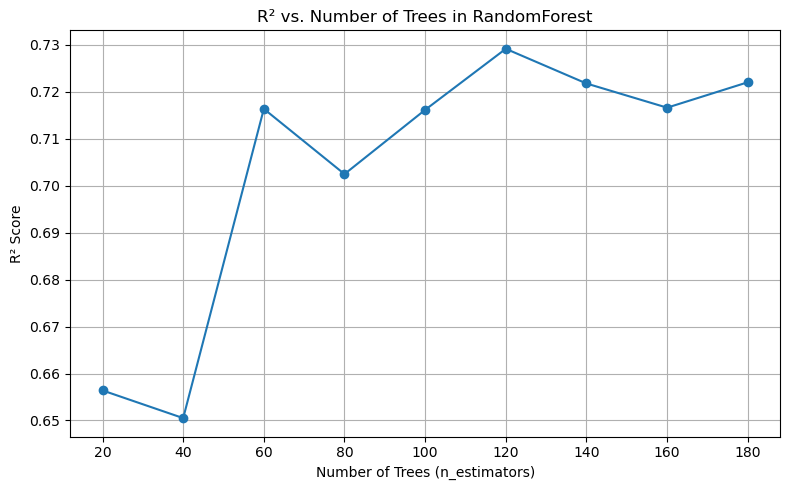

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

r2_scores = []
tree_counts = list(range(20, 200, 20))

#for t in [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]:
for t in tree_counts:
    model = RandomForestRegressor(n_estimators=t, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    r2_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, r2_scores, marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R² Score')
plt.title('R² vs. Number of Trees in RandomForest')
plt.grid(True)
plt.tight_layout()
plt.show()

0.6501695579450416
0.6466717264038232
0.6387533333333333
0.6474792891278377
0.6524691536439666
0.6530528989114563
0.6713780572013749
0.6802733467741934
0.6767615263212237
0.6746132675029866
0.6693781845828761
0.6749896091364658
0.673780821969134
0.6746767566381383
0.6747594806318853
0.6745332346270153
0.6745742522106873
0.6730578795521917
0.672127712381311
0.671358288112305
0.6685330216977269
0.6700394257580693
0.6676111945398657
0.6685677859086685


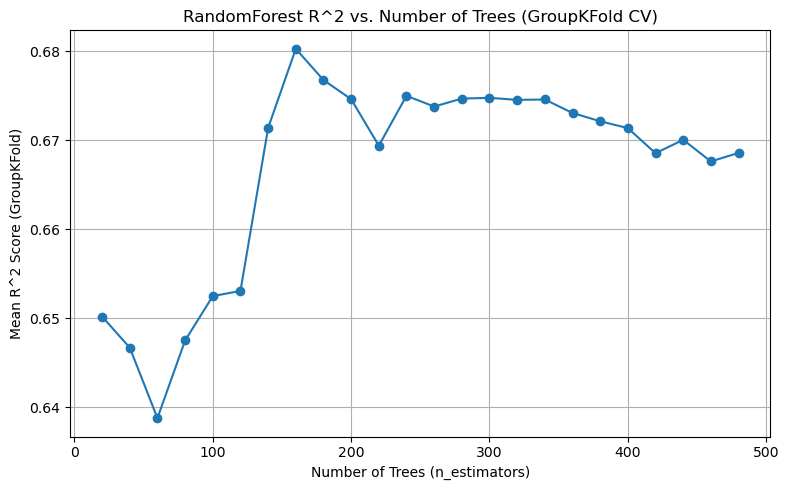

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

groups = np.repeat(np.arange(11), 3)
tree_counts = list(range(20, 200, 20)) 
gkf = GroupKFold(n_splits=5)
r2_scores = []

for n_tree in tree_counts:
    fold_scores = []
    for train_idx, test_idx in gkf.split(X, y, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model = RandomForestRegressor(n_estimators=n_tree, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)
        fold_scores.append(score)
    mean_r2 = np.mean(fold_scores)
    r2_scores.append(mean_r2)
    print(mean_r2)


plt.figure(figsize=(8, 5))
plt.plot(tree_counts, r2_scores, marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Mean R^2 Score (GroupKFold)')
plt.title('RandomForest R^2 vs. Number of Trees (GroupKFold CV)')
plt.grid(True)
plt.tight_layout()
plt.show()

K: 3, GroupKFold N-Components: 20, Mean CV MAE: 0.1252
K: 3, GroupKFold N-Components: 40, Mean CV MAE: 0.1295
K: 3, GroupKFold N-Components: 60, Mean CV MAE: 0.1331
K: 3, GroupKFold N-Components: 80, Mean CV MAE: 0.1281
K: 3, GroupKFold N-Components: 100, Mean CV MAE: 0.1291
K: 3, GroupKFold N-Components: 120, Mean CV MAE: 0.1250
K: 3, GroupKFold N-Components: 140, Mean CV MAE: 0.1244
K: 3, GroupKFold N-Components: 160, Mean CV MAE: 0.1230
K: 3, GroupKFold N-Components: 180, Mean CV MAE: 0.1234


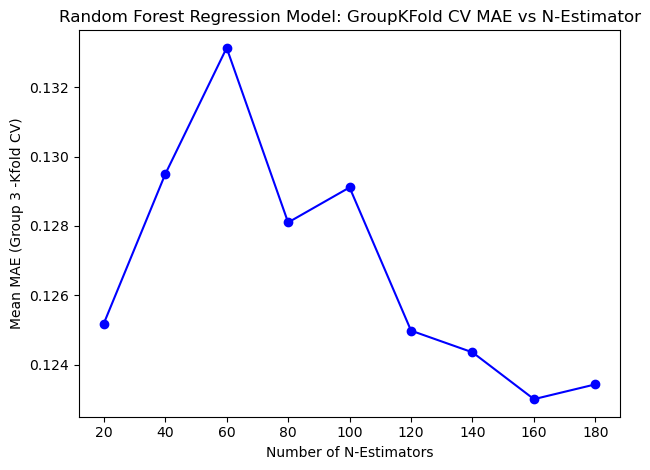

K: 5, GroupKFold N-Components: 20, Mean CV MAE: 0.1352
K: 5, GroupKFold N-Components: 40, Mean CV MAE: 0.1314
K: 5, GroupKFold N-Components: 60, Mean CV MAE: 0.1319
K: 5, GroupKFold N-Components: 80, Mean CV MAE: 0.1310
K: 5, GroupKFold N-Components: 100, Mean CV MAE: 0.1310
K: 5, GroupKFold N-Components: 120, Mean CV MAE: 0.1301
K: 5, GroupKFold N-Components: 140, Mean CV MAE: 0.1273
K: 5, GroupKFold N-Components: 160, Mean CV MAE: 0.1261
K: 5, GroupKFold N-Components: 180, Mean CV MAE: 0.1275


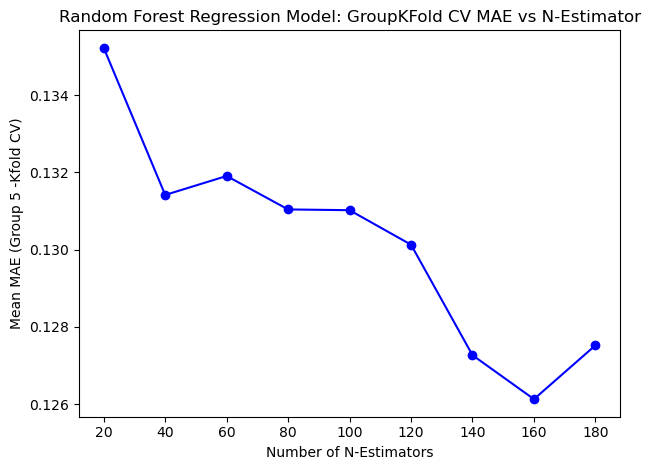

K: 7, GroupKFold N-Components: 20, Mean CV MAE: 0.1173
K: 7, GroupKFold N-Components: 40, Mean CV MAE: 0.1167
K: 7, GroupKFold N-Components: 60, Mean CV MAE: 0.1163
K: 7, GroupKFold N-Components: 80, Mean CV MAE: 0.1173
K: 7, GroupKFold N-Components: 100, Mean CV MAE: 0.1165
K: 7, GroupKFold N-Components: 120, Mean CV MAE: 0.1173
K: 7, GroupKFold N-Components: 140, Mean CV MAE: 0.1164
K: 7, GroupKFold N-Components: 160, Mean CV MAE: 0.1169
K: 7, GroupKFold N-Components: 180, Mean CV MAE: 0.1167


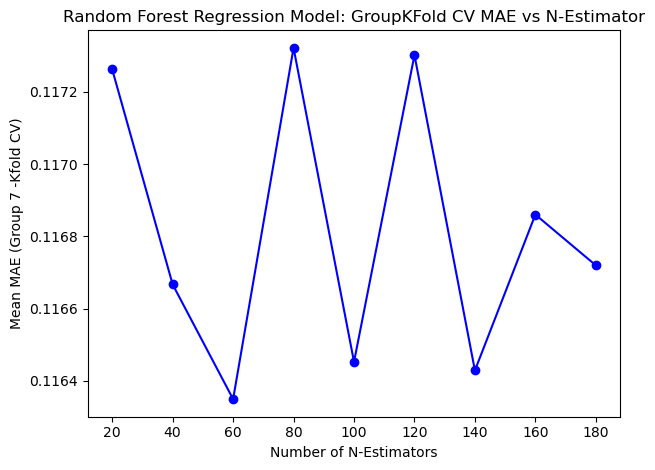

K: 9, GroupKFold N-Components: 20, Mean CV MAE: 0.1301
K: 9, GroupKFold N-Components: 40, Mean CV MAE: 0.1287
K: 9, GroupKFold N-Components: 60, Mean CV MAE: 0.1298
K: 9, GroupKFold N-Components: 80, Mean CV MAE: 0.1281
K: 9, GroupKFold N-Components: 100, Mean CV MAE: 0.1273
K: 9, GroupKFold N-Components: 120, Mean CV MAE: 0.1288
K: 9, GroupKFold N-Components: 140, Mean CV MAE: 0.1294
K: 9, GroupKFold N-Components: 160, Mean CV MAE: 0.1280
K: 9, GroupKFold N-Components: 180, Mean CV MAE: 0.1289


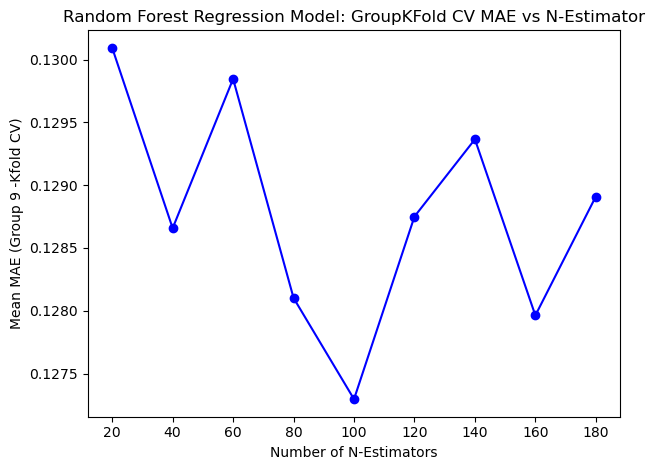

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
groups = [i // 3 for i in range(len(files))]  
from sklearn.model_selection import GroupKFold

tree_counts = list(range(20, 200, 20)) 
#k = 5
#r2_cv_scores = []
#color = ['red', 'blue', 'green', 'yellow']
#gkf = GroupKFold(n_splits=k)

for k in [3, 5, 7, 9]:
    mae_cv_scores = []
    plt.figure()
    gkf = GroupKFold(n_splits=k)
    for n_tree in tree_counts:
        fold_scores = []
        for train_idx, test_idx in gkf.split(X, y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=n_tree, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = mean_absolute_error(y_test, y_pred)
            fold_scores.append(score)
        mean_score = np.mean(fold_scores)
        mae_cv_scores.append((n_tree, mean_score))
        print(f"K: {k}, GroupKFold N-Components: {n_tree}, Mean CV MAE: {mean_score:.4f}")
    mae_df = pd.DataFrame(mae_cv_scores, columns=['n_estimators', 'mean_mae'])
    plt.plot(mae_df['n_estimators'], mae_df['mean_mae'], marker='o', color= 'blue')
    plt.xlabel('Number of N-Estimators')
    plt.ylabel(f'Mean MAE (Group {k} -Kfold CV)')
    plt.title('Random Forest Regression Model: GroupKFold CV MAE vs N-Estimator')
    plt.tight_layout()
    plt.show()

n_estimators=20, k=3, Mean MAE: 0.1252
n_estimators=20, k=5, Mean MAE: 0.1352
n_estimators=20, k=7, Mean MAE: 0.1173
n_estimators=20, k=9, Mean MAE: 0.1301
n_estimators=20, Overall Avg MAE across k=3,5,7,9: 0.1269
n_estimators=40, k=3, Mean MAE: 0.1295
n_estimators=40, k=5, Mean MAE: 0.1314
n_estimators=40, k=7, Mean MAE: 0.1167
n_estimators=40, k=9, Mean MAE: 0.1287
n_estimators=40, Overall Avg MAE across k=3,5,7,9: 0.1266
n_estimators=60, k=3, Mean MAE: 0.1331
n_estimators=60, k=5, Mean MAE: 0.1319
n_estimators=60, k=7, Mean MAE: 0.1163
n_estimators=60, k=9, Mean MAE: 0.1298
n_estimators=60, Overall Avg MAE across k=3,5,7,9: 0.1278
n_estimators=80, k=3, Mean MAE: 0.1281
n_estimators=80, k=5, Mean MAE: 0.1310
n_estimators=80, k=7, Mean MAE: 0.1173
n_estimators=80, k=9, Mean MAE: 0.1281
n_estimators=80, Overall Avg MAE across k=3,5,7,9: 0.1261
n_estimators=100, k=3, Mean MAE: 0.1291
n_estimators=100, k=5, Mean MAE: 0.1310
n_estimators=100, k=7, Mean MAE: 0.1165
n_estimators=100, k=9, M

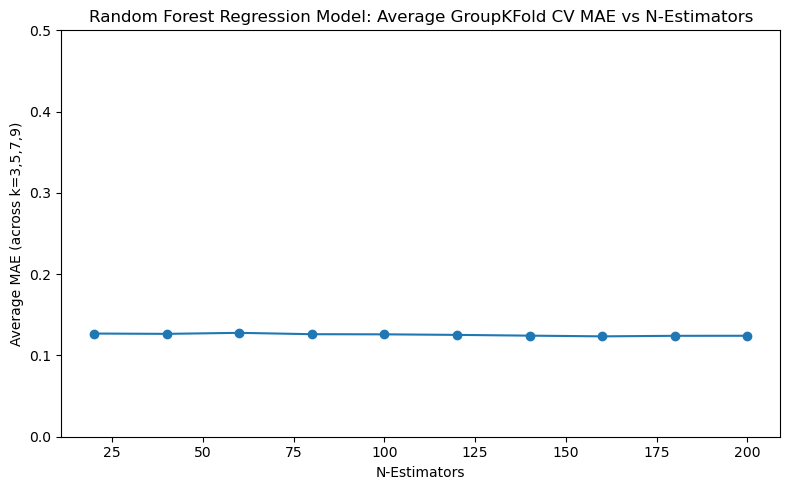

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error 
from sklearn.model_selection import GroupKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

groups = [i // 3 for i in range(len(files))] 
tree_counts = list(range(20, 220, 20)) 

final_scores = [] 

for n_tree in tree_counts:
    mae_for_k = [] 
    
    for k in [3, 5, 7, 9]:
        gkf = GroupKFold(n_splits=k)
        fold_maes = []
        
        for train_idx, test_idx in gkf.split(X, y, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model = RandomForestRegressor(n_estimators=n_tree, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            mae = mean_absolute_error(y_test, y_pred)
            fold_maes.append(mae)
        
        mean_mae_k = np.mean(fold_maes)
        print(f"n_estimators={n_tree}, k={k}, Mean MAE: {mean_mae_k:.4f}")
        mae_for_k.append(mean_mae_k)
    
    overall_avg_mae = np.mean(mae_for_k)
    print(f"n_estimators={n_tree}, Overall Avg MAE across k=3,5,7,9: {overall_avg_mae:.4f}")
    final_scores.append((n_tree, overall_avg_mae))
final_df = pd.DataFrame(final_scores, columns=['n_components', 'avg_mae'])

plt.figure(figsize=(8,5))
plt.plot(final_df['n_components'], final_df['avg_mae'], marker='o')
plt.ylim(0, 0.5)
plt.xlabel('N-Estimators')
plt.ylabel('Average MAE (across k=3,5,7,9)')
plt.title('Random Forest Regression Model: Average GroupKFold CV MAE vs N-Estimators')
plt.tight_layout()
plt.show()